## Model Comparison

The goal of this notebook is to compare the performance of the four different models in our classification task.

In [1]:
import joblib
import torch
import pandas as pd
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

#### Loading the models

In [9]:
# Load the models
# Logistic Regression, Random Forest, and XGBoost can be loaded from joblib files directly
logisticRegression = joblib.load('../models/logistic_regression_model.joblib')
randomForest = joblib.load('../models/random_forest_model.joblib')
XGBoost = joblib.load('../models/XGBoost_model.joblib')

# The neural network model class needs to be defined again
class WildfireNet(torch.nn.Module):
    def __init__(self, input_size, K1, K2, dropout_p):
        # Call base class constructor
        super(WildfireNet, self).__init__()

        # Define layers explicitly using torch.nn
        self.fc1 = torch.nn.Linear(input_size, K1)
        self.fc2 = torch.nn.Linear(K1, K2)
        self.fc3 = torch.nn.Linear(K2, 1)

        # We want a batchnorm after the second layer
        self.batchnorm = torch.nn.BatchNorm1d(K2)

        # And a dropout
        self.dropout = torch.nn.Dropout(dropout_p, inplace=False)

    def forward(self, x):

        if x.ndim > 2:
            x = torch.flatten(x, start_dim=1)  # Flatten if needed

        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.batchnorm(self.fc2(x)))
        x = self.dropout(x)
        z = self.fc3(x)

        return z

# Initialize the network structure
neuralNetwork = WildfireNet(input_size=24, K1=64, K2=32, dropout_p=0.5)

# Load the saved model weights
neuralNetwork.load_state_dict(torch.load("../models/neural_net.pth"))


<All keys matched successfully>

#### Preparing the test data

In [4]:
# Load the test data for comparison
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv')
df['Vegetation'] = df['Vegetation'].astype('category')
dummy_cols = [col for col in df.columns if col.startswith('Vegetation_')]

X_onehot = df.drop(columns=['Vegetation','catastrophic','index'])
X_cat = df.drop(columns=['catastrophic','index',*dummy_cols])
y = df['catastrophic']

X_train_onehot, X_test_onehot, y_train, y_test = train_test_split(X_onehot, y, test_size=0.2, stratify=y, random_state=42)
X_train_cat, X_test_cat, y_train, y_test = train_test_split(X_cat, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train_onehot)
X_train_onehot_scaled = scaler.transform(X_train_onehot)
X_test_onehot_scaled = scaler.transform(X_test_onehot)

# Again, we do it a bit differently for the neural network
# Unfortunately, we need to redefine our dataset class.
# Best practice would be to define the classes in a separate py file and import them.
# But for the sake of simplicity and keeping everything in notebooks, we will define it here.
class WildfireDataset(torch.utils.data.Dataset):
    def __init__(self, X, T, transform=None):

        # Convert to tensors if needed
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)

        # Store inputs
        self.inputs = X

        # Encode string labels to integer class indices
        unique_labels = sorted(set(T))
        self.label2index = {label: idx for idx, label in enumerate(unique_labels)}
        # Store encoded targets
        self.targets = torch.tensor([self.label2index[label] for label in T], dtype=torch.float32)


        # Store transform
        self.transform = transform


    def __getitem__(self, index):
        # get input and target for the given index
        input = self.inputs[index]
        target = self.targets[index]

        # Apply optional transform (e.g., normalization)
        if self.transform:
            input = self.transform(input)

        # return both the input sample and its target class
        return input, target


    def __len__(self):
        # return the number of samples in our dataset
        return len(self.inputs)
    
dataset_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data/interim/neuralNet_test_dataset.pth"))
NeuralNet_test_dataset = torch.load(dataset_path, weights_only=False)
test_loader  = torch.utils.data.DataLoader(NeuralNet_test_dataset, batch_size=128, shuffle=False)

#### Computing the predictions

In [29]:
# Logistic Model with default threshold
y_pred_logistic = logisticRegression.predict(X_test_onehot_scaled)

# Logistic Model with custom decision threshold
y_pred_proba_logistic = logisticRegression.predict_proba(X_test_onehot_scaled)[:, 1]
logistic_threshold = 0.47
y_pred_logistic_custom = (y_pred_proba_logistic >= logistic_threshold).astype(int)
# ----------------------------------------------------------------------------------------

# Random Forest with default decision threshold
y_pred_random_forest = randomForest.predict(X_test_onehot)

# Random Forest with custom decision threshold
y_pred_proba_random_forest = randomForest.predict_proba(X_test_onehot)[:, 1]
rf_threshold = 0.45
y_pred_rf_custom = (y_pred_proba_random_forest >= rf_threshold).astype(int)
# ----------------------------------------------------------------------------------------

# XGBoost
y_pred_XGBoost = XGBoost.predict(X_test_cat)
y_pred_proba_XGBoost = XGBoost.predict_proba(X_test_cat)[:, 1]
# ----------------------------------------------------------------------------------------

# Neural Network
neuralNetwork.eval()  # Set to evaluation mode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
neuralNetwork.to(device)

y_pred_neural, y_pred_proba_neural, y_test_neural = [], [], []

neural_threshold = 0.43
# Disable gradient calculation for efficiency
with torch.no_grad():
    for x, t in test_loader:
        x = x.to(device)
        z = neuralNetwork(x)
        probabilities = torch.sigmoid(z.squeeze(1))
        # Threshold at 0.5 to get predicted classes (0 or 1)
        predicted_classes = (probabilities >= neural_threshold).int()

        # Move data to CPU
        y_pred_neural.extend(predicted_classes.cpu())
        y_pred_proba_neural.extend(probabilities.cpu())
        y_test_neural.extend(t)

# Convert all lists to torch tensors
print("test_predictions", y_pred_neural)
y_pred_neural = torch.tensor(y_pred_neural)
y_pred_proba_neural = torch.tensor(y_pred_proba_neural)
y_test_neural = torch.tensor(y_test_neural)


test_predictions [tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(1, dtype=torch.

In [19]:
# Neural Network
neuralNetwork.eval()  # Set to evaluation mode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
neuralNetwork.to(device)

y_pred_neural, y_pred_proba_neural, y_test_neural = [], [], []

neural_threshold = 0.43
# Disable gradient calculation for efficiency
with torch.no_grad():
    for x, t in test_loader:
        x = x.to(device)
        z = neuralNetwork(x)
        probabilities = torch.sigmoid(z.squeeze(1))
        # Threshold at 0.5 to get predicted classes (0 or 1)
        predicted_classes = (probabilities >= neural_threshold).int()

        # Move data to CPU
        y_pred_neural.extend(predicted_classes.cpu())
        y_pred_proba_neural.extend(probabilities.cpu())
        y_test_neural.extend(t)

# Convert all lists to torch tensors
print("test_predictions", y_pred_neural)
y_pred_neural = torch.tensor(y_pred_neural)
y_pred_proba_neural = torch.tensor(y_pred_proba_neural)
y_test_neural = torch.tensor(y_test_neural)

test_predictions [tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(0, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(1, dtype=torch.int32), tensor(1, dtype=torch.

In [20]:
# Compare accuracy, recall, precision, and f1-score
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    return accuracy, recall, precision, f1, f1_weighted

# Logistic Regression
accuracy_logistic, recall_logistic, precision_logistic, f1_logistic, f1_logistic_weighted = evaluate_model(y_test, y_pred_logistic)
# Logistic Regression with custom threshold
accuracy_logistic_custom, recall_logistic_custom, precision_logistic_custom, f1_logistic_custom, f1_logistic_custom_weighted = evaluate_model(y_test, y_pred_logistic_custom)
# Random Forest
accuracy_random_forest, recall_random_forest, precision_random_forest, f1_random_forest, f1_random_forest_weighted = evaluate_model(y_test, y_pred_random_forest)
# Random Forest with custom threshold
accuracy_random_forest_custom, recall_random_forest_custom, precision_random_forest_custom, f1_random_forest_custom, f1_random_forest_custom_weighted = evaluate_model(y_test, y_pred_rf_custom)
# XGBoost
accuracy_XGBoost, recall_XGBoost, precision_XGBoost, f1_XGBoost, f1_XGBoost_weighted = evaluate_model(y_test, y_pred_XGBoost)
# Neural Network with custom threshold
accuracy_neural, recall_neural, precision_neural, f1_neural, f1_neural_weighted = evaluate_model(y_test_neural, y_pred_neural)

# Print the results in a table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 
              f'Logistic Regression with threshold:{logistic_threshold}', 
              'Random Forest', 
              f'Random Forest with threshold:{rf_threshold}', 
              'XGBoost',
              f'Neural Network with threshold:{neural_threshold}'],
    'Accuracy': [accuracy_logistic, accuracy_logistic_custom, accuracy_random_forest, accuracy_random_forest_custom, accuracy_XGBoost, accuracy_neural],
    'Recall': [recall_logistic, recall_logistic_custom, recall_random_forest, recall_random_forest_custom, recall_XGBoost, recall_neural],
    'Precision': [precision_logistic, precision_logistic_custom, precision_random_forest, precision_random_forest_custom, precision_XGBoost, precision_neural],
    'F1-Score': [f1_logistic, f1_logistic_custom, f1_random_forest, f1_random_forest_custom, f1_XGBoost, f1_neural],
    'F1-Score (weighted)': [f1_logistic_weighted, f1_logistic_custom_weighted, f1_random_forest_weighted, f1_random_forest_custom_weighted, f1_XGBoost_weighted, f1_neural_weighted]
})
results = results.set_index('Model')
results = results.sort_values(by='F1-Score', ascending=False)
display(results)


,Accuracy,Recall,Precision,F1-Score,F1-Score (weighted)
Model,,,,,
XGBoost,0.684493,0.696934,0.534047,0.604714,0.691504
Random Forest with threshold:0.45,0.681134,0.692666,0.530303,0.600707,0.688231
Neural Network with threshold:0.43,0.647675,0.715561,0.493973,0.584469,0.656197
Random Forest,0.732061,0.536671,0.633532,0.581092,0.726186
Logistic Regression with threshold:0.47,0.602392,0.647652,0.448656,0.530094,0.612015
Logistic Regression,0.658022,0.542103,0.505793,0.523319,0.660633


#### The Role of Thresholds

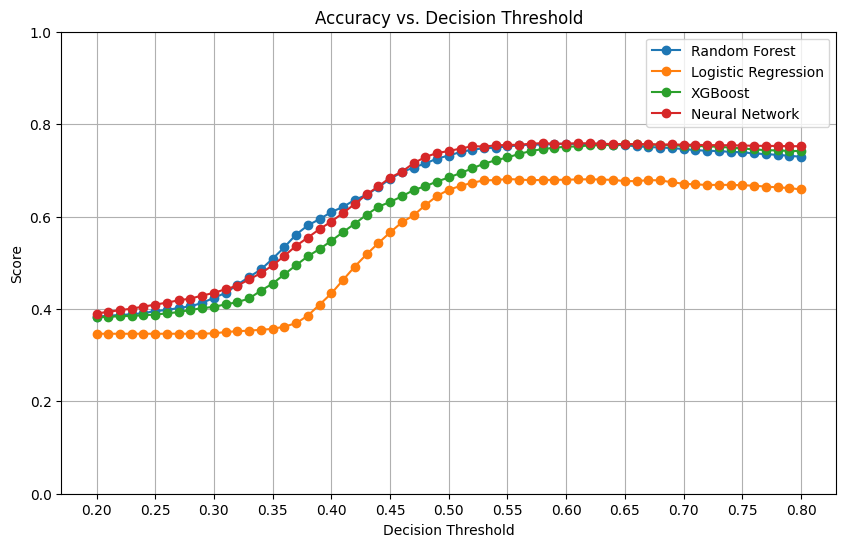

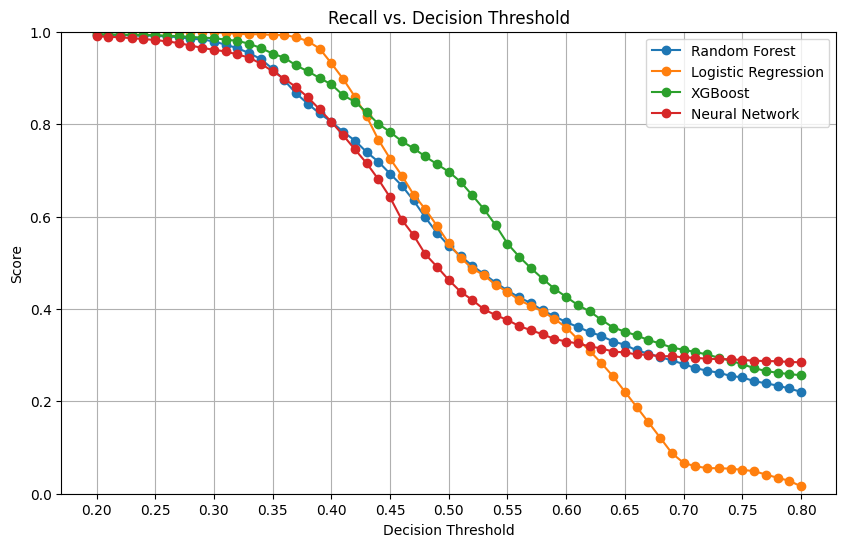

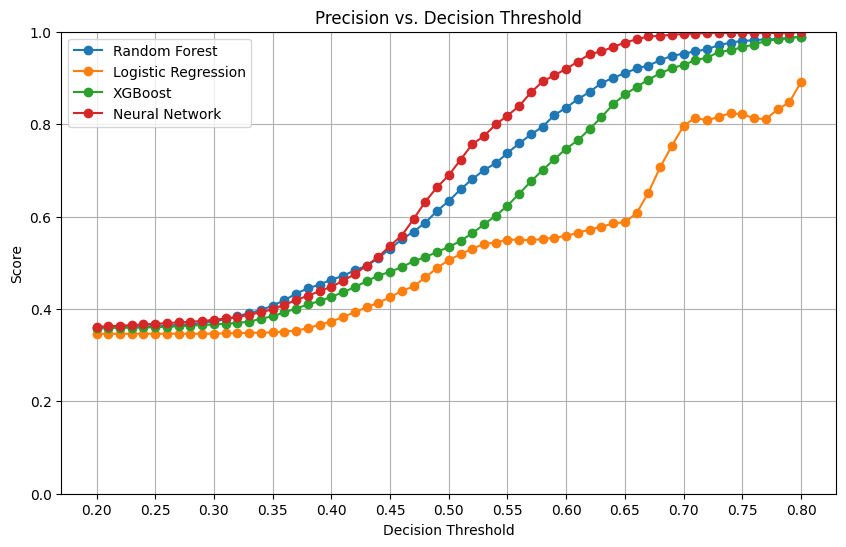

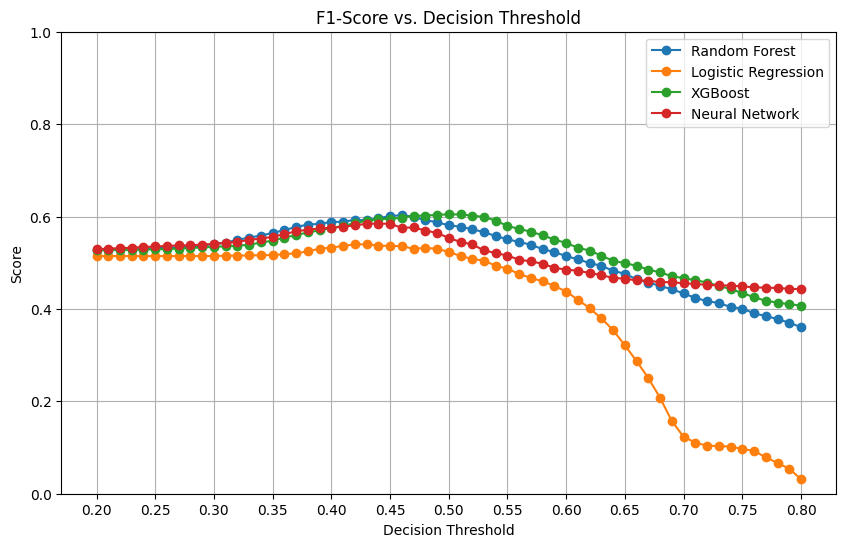

In [32]:
metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
for metric in range(4):
    scores_rf = []
    scores_log = []
    scores_xgboost = []
    scores_neural = []
    # iterate over the thresholds from 0.4 to 0.6 in steps of 0.01
    for threshold in range(20, 81):
        threshold = threshold / 100
        # Random Forest
        y_pred_rf_custom = (y_pred_proba_random_forest >= threshold).astype(int)
        accuracy_random_forest_custom, recall_random_forest_custom, precision_random_forest_custom, f1_random_forest_custom, f1_random_forest_custom_weighted = evaluate_model(y_test, y_pred_rf_custom)
        scores_rf.append([accuracy_random_forest_custom, recall_random_forest_custom, precision_random_forest_custom, f1_random_forest_custom][metric])

        # Logistic Regression
        y_pred_logistic_custom = (y_pred_proba_logistic >= threshold).astype(int)
        accuracy_logistic_custom, recall_logistic_custom, precision_logistic_custom, f1_logistic_custom, f1_logistic_custom_weighted = evaluate_model(y_test, y_pred_logistic_custom)
        scores_log.append([accuracy_logistic_custom, recall_logistic_custom, precision_logistic_custom, f1_logistic_custom][metric])

        # XGBoost
        y_pred_XGBoost_custom = (y_pred_proba_XGBoost >= threshold).astype(int)
        accuracy_XGBoost_custom, recall_XGBoost_custom, precision_XGBoost_custom, f1_XGBoost_custom, f1_XGBoost_custom_weighted = evaluate_model(y_test, y_pred_XGBoost_custom)
        scores_xgboost.append([accuracy_XGBoost_custom, recall_XGBoost_custom, precision_XGBoost_custom, f1_XGBoost_custom][metric])
        
        # Neural Network
        y_pred_neural = (y_pred_proba_neural >= threshold).int()
        accuracy_neural, recall_neural, precision_neural, f1_neural, f1_neural_weighted = evaluate_model(y_test_neural, y_pred_neural)
        scores_neural.append([accuracy_neural, recall_neural, precision_neural, f1_neural][metric])
    
    # Plot the results
    import matplotlib.pyplot as plt
    import numpy as np
    thresholds = np.arange(0.20, 0.80, 0.01)
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, scores_rf, label='Random Forest', marker='o')
    plt.plot(thresholds, scores_log, label='Logistic Regression', marker='o')
    plt.plot(thresholds, scores_xgboost, label='XGBoost', marker='o')
    plt.plot(thresholds, scores_neural, label='Neural Network', marker='o')
    plt.title(f'{metrics[metric]} vs. Decision Threshold')
    plt.xlabel('Decision Threshold')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    # only show every 5th tick
    plt.xticks(thresholds[::5])
    plt.grid()
    plt.legend()
    plt.show()